In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Fine-Tuning Pretrained Transformer Models for Hate Speech Detection
## TRIA Assignment 2026 — Main Study

**Module:** Techniques de Recherche d'Information Avancée (TRIA)  
**Level:** Master 1 Data Science  
**Task:** Hate Speech Detection  
**Main Dataset:** HateXplain  

### Objective
This notebook presents the main study of our TRIA assignment on fine-tuning pretrained transformer models for a downstream text classification task. The selected task is **hate speech detection**, and the main dataset used is **HateXplain**.

We compare a classical TF-IDF + Logistic Regression baseline against three pretrained transformer models — **DistilBERT**, **RoBERTa** (with class-weighted loss), and **HateBERT** (domain-specific, pretrained on hate speech data). We further combine these three models into a **soft-voting ensemble** as a bonus experiment. The full pipeline covers dataset loading, preprocessing, fine-tuning, evaluation (Accuracy, Precision, Recall, F1), learning curves, confusion matrices, and a final multi-model comparison.

# 1. Assignment Framing and Task Overview

The goal of this TRIA assignment is to understand how to **fine-tune a pretrained transformer model** for a downstream NLP task. The required workflow includes:
1. understanding transformer models and fine-tuning,
2. selecting a public text classification dataset,
3. preprocessing the text data,
4. choosing a pretrained model from Hugging Face,
5. defining training arguments,
6. fine-tuning the model,
7. evaluating the results with appropriate metrics,
8. and presenting the work in a notebook, report, and short presentation.

We chose **Hate Speech Detection** as the main task. The objective is to classify a given social media post as hateful, offensive, or normal. This notebook constitutes the **main study** of the project; a second notebook (Bonus) extends the work to Arabic hate speech detection.

# 2. Brief Theory: Transformers and Fine-Tuning

Transformer models have become central tools in Natural Language Processing because they model relationships between words using contextual representations. Unlike traditional methods that rely on isolated words or handcrafted features, transformers process input as a sequence and capture long-range dependencies.

A **pretrained transformer** is first trained on a very large text corpus using a general language-learning objective, acquiring broad linguistic knowledge. **Fine-tuning** then continues this training on a task-specific labeled dataset, adapting the model's representations to the target classes. This process is highly efficient because it starts from a powerful linguistic prior rather than learning from scratch.

In this notebook we compare three pretrained encoder models:
- **DistilBERT** — a lighter, faster BERT variant,
- **RoBERTa** — a robustly optimized BERT with stronger representations,
- **HateBERT** — a BERT model pretrained specifically on 100 million hate-speech Reddit posts.

A soft-voting **ensemble** combining all three models is also evaluated as an advanced bonus experiment.

# 3. Why We Chose HateXplain

We selected **hate speech detection** because it offers a strong balance between academic relevance, dataset availability, and modeling depth. Harmful language is often subtle, making transformer-based contextual representations particularly useful.

For the main study we chose **HateXplain** because:
- it supports a **multiclass formulation** (hateful / offensive / normal), which is more informative than binary classification,
- it is widely used in academic hate speech research,
- it provides official train/validation/test splits for reproducible evaluation,
- and the ambiguous boundary between offensive and hateful content provides a genuine challenge for all model types.

# 4. Environment and Imports

In [ ]:
!pip install -q "datasets==3.6.0" "transformers==4.53.3" "huggingface_hub==0.34.4" "accelerate>=0.30"

In [ ]:
# Core libraries
import os, re, random, warnings, json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

# Hugging Face
from datasets import load_dataset, Dataset
import torch
from torch.nn import CrossEntropyLoss
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer)

warnings.filterwarnings("ignore")

In [ ]:
# Reproducibility
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")

# Device check
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Seed set to 42
Using device: cuda
GPU: Tesla T4


# 5. Load the Dataset

We use **HateXplain**, a publicly available dataset for hate speech analysis on Hugging Face. Each example contains a social media post tokenized as a list, multiple annotator labels, and rationale annotations. We use majority voting across annotators to assign a single label per example.

In [ ]:
# Load HateXplain from Hugging Face
raw_dataset = load_dataset("Hate-speech-CNERG/hatexplain")
raw_dataset

The repository for Hate-speech-CNERG/hatexplain contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/Hate-speech-CNERG/hatexplain.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/15383 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1922 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1924 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 15383
    })
    validation: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1922
    })
    test: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1924
    })
})

In [ ]:
# Inspect one raw example
raw_dataset["train"][0]

{'id': '23107796_gab',
 'annotators': {'label': [0, 2, 2],
  'annotator_id': [203, 204, 233],
  'target': [['Hindu', 'Islam'],
   ['Hindu', 'Islam'],
   ['Hindu', 'Islam', 'Other']]},
 'rationales': [[0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   1,
   1,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0],
  [0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   1,
   1,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   0]],
 'post_tokens': ['u',
  'really',
  'think',
  'i',
  'would',
  'not',
  'have',
  'been',
  'raped',
  'by',
  'feral',
  'hindu',
  'or',
  'muslim',
  'back',
  'in',
  'india',
  'or',
  'bangladesh',
  'and',
  'a',
  'neo',
  'nazi',
  'would',
  'rape',
  'me',
  'as',
  'well',
  'just',
  'to',
  'see',
  'me',
  'cry']}

# 6. Exploratory Data Analysis

We transform the raw dataset into a tabular format by joining the token lists and applying majority-vote labeling, then study class distribution and text length.

In [ ]:
def safe_join_tokens(post_tokens):
    if isinstance(post_tokens, list):
        return " ".join(post_tokens)
    return str(post_tokens)

def extract_majority_label(example):
    """Majority vote across annotators."""
    labels = example.get("annotators", {}).get("label", [])
    if not labels:
        return None
    return Counter(labels).most_common(1)[0][0]

def simplify_split(hf_split):
    rows = []
    for ex in hf_split:
        rows.append({
            "text": safe_join_tokens(ex.get("post_tokens", [])),
            "label_id": extract_majority_label(ex)
        })
    return pd.DataFrame(rows)

train_df = simplify_split(raw_dataset["train"])
val_df   = simplify_split(raw_dataset["validation"])
test_df  = simplify_split(raw_dataset["test"])

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (15383, 2)
Validation shape: (1922, 2)
Test shape: (1924, 2)


In [ ]:
# Label mapping
label_map = {0: "hateful", 1: "normal", 2: "offensive"}
id2label  = label_map
label2id  = {v: k for k, v in id2label.items()}

for df in [train_df, val_df, test_df]:
    df["label_name"] = df["label_id"].map(label_map)

print("id2label:", id2label)
print("label2id:", label2id)
train_df.head()

id2label: {0: 'hateful', 1: 'normal', 2: 'offensive'}
label2id: {'hateful': 0, 'normal': 1, 'offensive': 2}


,text,label_id,label_name
0,u really think i would not have been raped by ...,2,offensive
1,the uk has threatened to return radioactive wa...,2,offensive
2,if english is not imposition then hindi is als...,2,offensive
3,no liberal congratulated hindu refugees post c...,2,offensive
4,he said bro even your texts sound redneck what...,2,offensive


In [ ]:
# Class distribution
label_counts = train_df["label_name"].value_counts(dropna=False)
print("Class distribution in training set:")
print(label_counts)
print()

# Percentage per split
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    pct = df["label_name"].value_counts(normalize=True).round(4) * 100
    print(f"{name} percentages:")
    print(pct)
    print()

Class distribution in training set:
label_name
normal       6251
hateful      4748
offensive    4384
Name: count, dtype: int64

Train percentages:
label_name
normal       40.64
hateful      30.87
offensive    28.50
Name: proportion, dtype: float64

Validation percentages:
label_name
normal       40.63
hateful      30.85
offensive    28.51
Name: proportion, dtype: float64

Test percentages:
label_name
normal       40.64
hateful      30.87
offensive    28.48
Name: proportion, dtype: float64



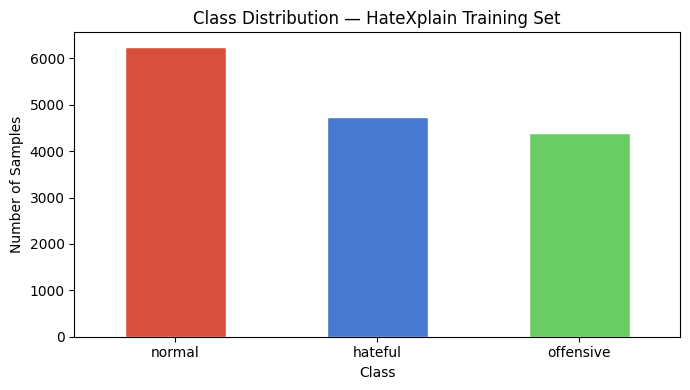

In [ ]:
# Class distribution bar chart
plt.figure(figsize=(7, 4))
label_counts.plot(kind="bar", color=["#d94f3d", "#4878cf", "#6acc65"], edgecolor="white")
plt.title("Class Distribution — HateXplain Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

count    15383.0
mean        23.5
std         13.8
min          2.0
25%         12.0
50%         21.0
75%         34.0
max        165.0
Name: word_length, dtype: float64


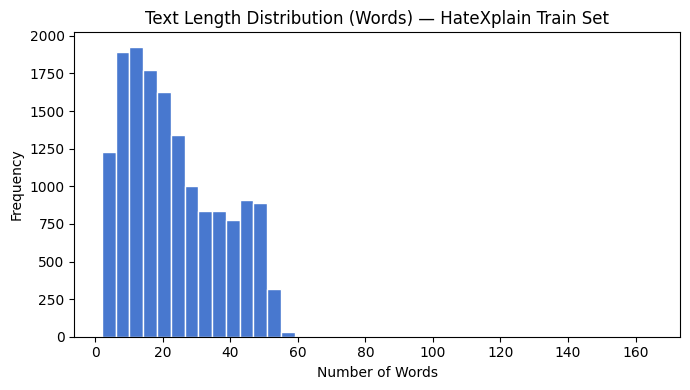

In [ ]:
# Text length analysis
train_df["word_length"] = train_df["text"].apply(lambda x: len(str(x).split()))

print(train_df["word_length"].describe().round(1))

plt.figure(figsize=(7, 4))
plt.hist(train_df["word_length"], bins=40, color="#4878cf", edgecolor="white")
plt.title("Text Length Distribution (Words) — HateXplain Train Set")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### EDA Summary

1. The dataset simplifies into standard (text, label) format with three classes: **hateful**, **normal**, **offensive**.
2. Class distribution is **moderately imbalanced** — normal is slightly overrepresented (~40%), hateful and offensive are each around 29–31%.
3. Texts are **short to medium length** (median ~21 words, max ~165 words), guiding our choice of max_length=128 for tokenization.
4. The offensive category is semantically closest to both hateful and normal content, which explains why it is the hardest class across all models.

# 7. Preprocessing Strategy

We adopt a **light preprocessing strategy** for transformers (preserve semantic content) and slightly stronger normalization for the classical baseline. Both strategies use the same split structure and label mapping throughout.

In [ ]:
# Working copies
train_proc = train_df.copy()
val_proc   = val_df.copy()
test_proc  = test_df.copy()

def clean_text_transformer(text):
    """Light cleaning for transformer models — preserve meaning."""
    text = str(text)
    text = text.replace("<user>", "USER")
    text = text.replace("<number>", "NUMBER")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_text_baseline(text):
    """Stronger normalization for TF-IDF baseline."""
    text = str(text).lower()
    text = text.replace("<user>", "user")
    text = text.replace("<number>", "number")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_proc, val_proc, test_proc]:
    df["text_clean"]    = df["text"].apply(clean_text_transformer)
    df["text_baseline"] = df["text"].apply(clean_text_baseline)

train_proc[["text", "text_clean", "text_baseline", "label_name"]].head(3)

,text,text_clean,text_baseline,label_name
0,u really think i would not have been raped by ...,u really think i would not have been raped by ...,u really think i would not have been raped by ...,offensive
1,the uk has threatened to return radioactive wa...,the uk has threatened to return radioactive wa...,the uk has threatened to return radioactive wa...,offensive
2,if english is not imposition then hindi is als...,if english is not imposition then hindi is als...,if english is not imposition then hindi is als...,offensive


In [ ]:
# Final label arrays for modeling
X_train_transformer = train_proc["text_clean"].tolist()
X_val_transformer   = val_proc["text_clean"].tolist()
X_test_transformer  = test_proc["text_clean"].tolist()

X_train_baseline = train_proc["text_baseline"].tolist()
X_val_baseline   = val_proc["text_baseline"].tolist()
X_test_baseline  = test_proc["text_baseline"].tolist()

y_train = train_proc["label_id"].tolist()
y_val   = val_proc["label_id"].tolist()
y_test  = test_proc["label_id"].tolist()

print("Train:", len(X_train_transformer), "| Val:", len(X_val_transformer), "| Test:", len(X_test_transformer))

Train: 15383 | Val: 1922 | Test: 1924


# 8. Shared Evaluation Helpers

We define reusable evaluation and visualization functions used throughout all model sections.

In [ ]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """Print and return a dict of all evaluation metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
    p_wt,  r_wt,  f1_wt,  _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n===== {model_name} =====")
    print(f"Accuracy            : {accuracy:.4f}")
    print(f"Precision (macro)   : {p_mac:.4f}")
    print(f"Recall    (macro)   : {r_mac:.4f}")
    print(f"F1        (macro)   : {f1_mac:.4f}")
    print(f"Precision (weighted): {p_wt:.4f}")
    print(f"Recall    (weighted): {r_wt:.4f}")
    print(f"F1        (weighted): {f1_wt:.4f}")

    return dict(Model=model_name, Accuracy=accuracy,
                Precision_macro=p_mac, Recall_macro=r_mac, F1_macro=f1_mac,
                Precision_weighted=p_wt, Recall_weighted=r_wt, F1_weighted=f1_wt)


def plot_confusion_matrix(y_true, y_pred, labels, title="Confusion Matrix"):
    """Plot a labelled confusion matrix."""
    cm_arr = confusion_matrix(y_true, y_pred, labels=list(labels.keys()))
    fig, ax = plt.subplots(figsize=(6, 5))
    cax = ax.imshow(cm_arr, cmap="Blues")
    plt.colorbar(cax, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels([labels[i] for i in labels], rotation=45, ha="right")
    ax.set_yticklabels([labels[i] for i in labels])
    for i in range(cm_arr.shape[0]):
        for j in range(cm_arr.shape[1]):
            ax.text(j, i, cm_arr[i, j], ha="center", va="center",
                    color="white" if cm_arr[i, j] > cm_arr.max() / 2 else "black")
    plt.tight_layout()
    plt.show()


def compute_metrics(eval_pred):
    """Hugging Face Trainer compute_metrics callback."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, preds)
    p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(labels, preds, average="macro",    zero_division=0)
    p_wt,  r_wt,  f1_wt,  _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return dict(accuracy=accuracy,
                precision_macro=p_mac, recall_macro=r_mac, f1_macro=f1_mac,
                precision_weighted=p_wt, recall_weighted=r_wt, f1_weighted=f1_wt)


def plot_learning_curves(trainer, model_name="Model"):
    """Plot train loss and eval F1 per epoch from Trainer log history."""
    history = trainer.state.log_history
    epochs, train_loss, eval_f1 = [], [], []
    for entry in history:
        if "epoch" in entry and "loss" in entry and "eval_f1_macro" not in entry:
            epochs.append(entry["epoch"])
            train_loss.append(entry["loss"])
        if "eval_f1_macro" in entry:
            eval_f1.append((entry["epoch"], entry["eval_f1_macro"]))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, train_loss, marker="o", color="#4878cf")
    ax1.set_title(f"{model_name} — Training Loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)

    if eval_f1:
        ep, f1 = zip(*eval_f1)
        ax2.plot(ep, f1, marker="s", color="#6acc65")
        ax2.set_title(f"{model_name} — Validation Macro F1")
        ax2.set_xlabel("Epoch"); ax2.set_ylabel("F1 (macro)")
        ax2.grid(True, alpha=0.3)

    plt.suptitle(f"Learning Curves — {model_name}", fontsize=13)
    plt.tight_layout()
    plt.show()

# 9. Prepare Hugging Face Dataset Objects

We convert our pandas DataFrames into Hugging Face `Dataset` objects. These are reused by all three transformer models.

In [ ]:
train_hf = Dataset.from_pandas(
    train_proc[["text_clean", "label_id"]].rename(columns={"text_clean": "text", "label_id": "label"}),
    preserve_index=False
)
val_hf = Dataset.from_pandas(
    val_proc[["text_clean", "label_id"]].rename(columns={"text_clean": "text", "label_id": "label"}),
    preserve_index=False
)
test_hf = Dataset.from_pandas(
    test_proc[["text_clean", "label_id"]].rename(columns={"text_clean": "text", "label_id": "label"}),
    preserve_index=False
)
print("train_hf:", train_hf)
print("val_hf:  ", val_hf)
print("test_hf: ", test_hf)

train_hf: Dataset({
    features: ['text', 'label'],
    num_rows: 15383
})
val_hf:   Dataset({
    features: ['text', 'label'],
    num_rows: 1922
})
test_hf:  Dataset({
    features: ['text', 'label'],
    num_rows: 1924
})


# 10. Baseline Model: TF-IDF + Logistic Regression

Before fine-tuning transformer models, we establish a classical baseline using TF-IDF vectorization and Logistic Regression. This gives us a reference point to measure the benefit of transformer-based approaches. We compare a standard variant and a class-weighted variant.

In [ ]:
# Standard baseline
baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)),
    ("clf",   LogisticRegression(max_iter=1000, random_state=SEED))
])
baseline_pipeline.fit(X_train_baseline, y_train)

y_test_pred_baseline = baseline_pipeline.predict(X_test_baseline)
baseline_test_results = evaluate_model(y_test, y_test_pred_baseline, "Baseline Standard (Test)")

print()
print(classification_report(y_test, y_test_pred_baseline,
      target_names=[id2label[i] for i in sorted(id2label)], digits=4, zero_division=0))


===== Baseline Standard (Test) =====
Accuracy            : 0.6736
Precision (macro)   : 0.6639
Recall    (macro)   : 0.6543
F1        (macro)   : 0.6542
Precision (weighted): 0.6671
Recall    (weighted): 0.6736
F1        (weighted): 0.6655

              precision    recall  f1-score   support

     hateful     0.7427    0.7290    0.7358       594
      normal     0.6746    0.7980    0.7311       782
   offensive     0.5745    0.4361    0.4959       548

    accuracy                         0.6736      1924
   macro avg     0.6639    0.6543    0.6542      1924
weighted avg     0.6671    0.6736    0.6655      1924



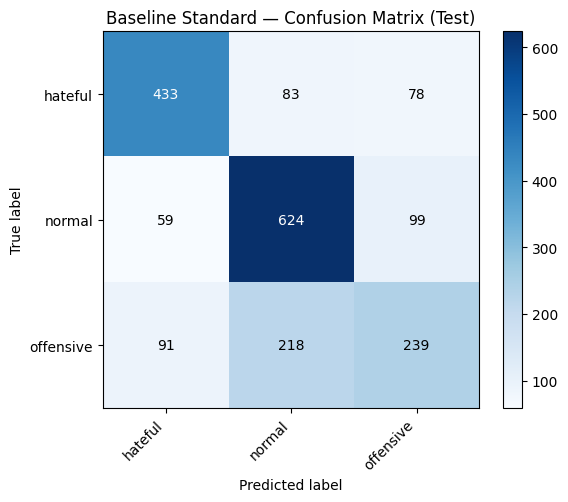

In [ ]:
plot_confusion_matrix(y_test, y_test_pred_baseline,
                      labels=id2label, title="Baseline Standard — Confusion Matrix (Test)")

In [ ]:
# Class-weighted baseline
baseline_pipeline_balanced = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)),
    ("clf",   LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
])
baseline_pipeline_balanced.fit(X_train_baseline, y_train)

y_test_pred_balanced = baseline_pipeline_balanced.predict(X_test_baseline)
baseline_bal_results = evaluate_model(y_test, y_test_pred_balanced, "Baseline Balanced (Test)")

print()
print(classification_report(y_test, y_test_pred_balanced,
      target_names=[id2label[i] for i in sorted(id2label)], digits=4, zero_division=0))


===== Baseline Balanced (Test) =====
Accuracy            : 0.6616
Precision (macro)   : 0.6517
Recall    (macro)   : 0.6535
F1        (macro)   : 0.6525
Precision (weighted): 0.6610
Recall    (weighted): 0.6616
F1        (weighted): 0.6612

              precision    recall  f1-score   support

     hateful     0.7178    0.7407    0.7291       594
      normal     0.7152    0.7033    0.7092       782
   offensive     0.5221    0.5164    0.5193       548

    accuracy                         0.6616      1924
   macro avg     0.6517    0.6535    0.6525      1924
weighted avg     0.6610    0.6616    0.6612      1924



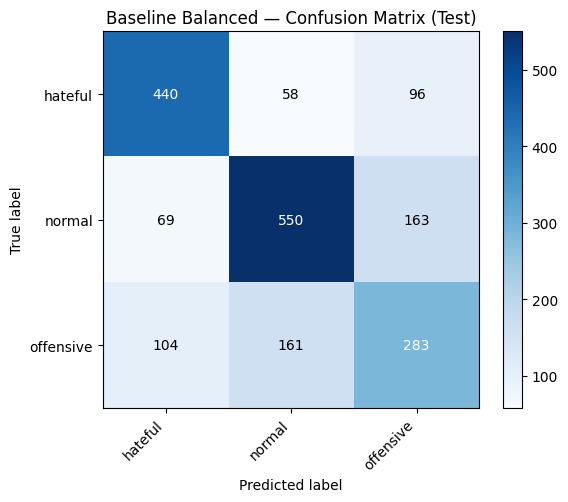


Selected baseline: Baseline Balanced


In [ ]:
plot_confusion_matrix(y_test, y_test_pred_balanced,
                      labels=id2label, title="Baseline Balanced — Confusion Matrix (Test)")

# Select best baseline
best_baseline_results = baseline_bal_results
best_baseline_name    = "Baseline Balanced"
y_test_pred_best_baseline = y_test_pred_balanced
print("\nSelected baseline:", best_baseline_name)

### Baseline Interpretation

The class-weighted Logistic Regression improves macro F1 by boosting recall on the **offensive** class, which is the hardest category. This is expected because the offensive class has the highest semantic ambiguity. The weighted variant is therefore selected as the final baseline for comparison.

The baseline establishes a competitive classical ceiling. Transformer models must clearly outperform this to justify their computational cost.

# 11. Transformer Model 1: DistilBERT

DistilBERT is a lighter and faster variant of BERT that retains most of its language understanding capability. It serves as our first transformer baseline, validating the fine-tuning pipeline before evaluating stronger models.

In [ ]:
DISTILBERT_NAME = "distilbert-base-uncased"
distilbert_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_NAME)

def tokenize_distilbert(examples):
    return distilbert_tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_train_db = train_hf.map(tokenize_distilbert, batched=True)
tokenized_val_db   = val_hf.map(tokenize_distilbert, batched=True)
tokenized_test_db  = test_hf.map(tokenize_distilbert, batched=True)

data_collator_db = DataCollatorWithPadding(tokenizer=distilbert_tokenizer)
print("Tokenization done. Example keys:", list(tokenized_train_db[0].keys()))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/15383 [00:00<?, ? examples/s]

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

Tokenization done. Example keys: ['text', 'label', 'input_ids', 'attention_mask']


In [ ]:
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

distilbert_args = TrainingArguments(
    output_dir="./results_distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=SEED
)

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_args,
    train_dataset=tokenized_train_db,
    eval_dataset=tokenized_val_db,
    data_collator=data_collator_db,
    compute_metrics=compute_metrics
)

print("DistilBERT trainer ready.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT trainer ready.


In [ ]:
# Fine-tune DistilBERT
distilbert_train_output = distilbert_trainer.train()
distilbert_train_output

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.788800,0.743559,0.690947,0.687034,0.671188,0.671532,0.686920,0.690947,0.681545
2,0.632000,0.725938,0.689386,0.680448,0.680245,0.680168,0.686854,0.689386,0.687948
3,0.511700,0.788020,0.679501,0.678811,0.680701,0.676884,0.691297,0.679501,0.682324
4,0.406900,0.864454,0.677940,0.666183,0.670756,0.667990,0.676604,0.677940,0.676794


TrainOutput(global_step=3848, training_loss=0.5848478051580164, metrics={'train_runtime': 440.9046, 'train_samples_per_second': 139.559, 'train_steps_per_second': 8.728, 'total_flos': 919551782648196.0, 'train_loss': 0.5848478051580164, 'epoch': 4.0})

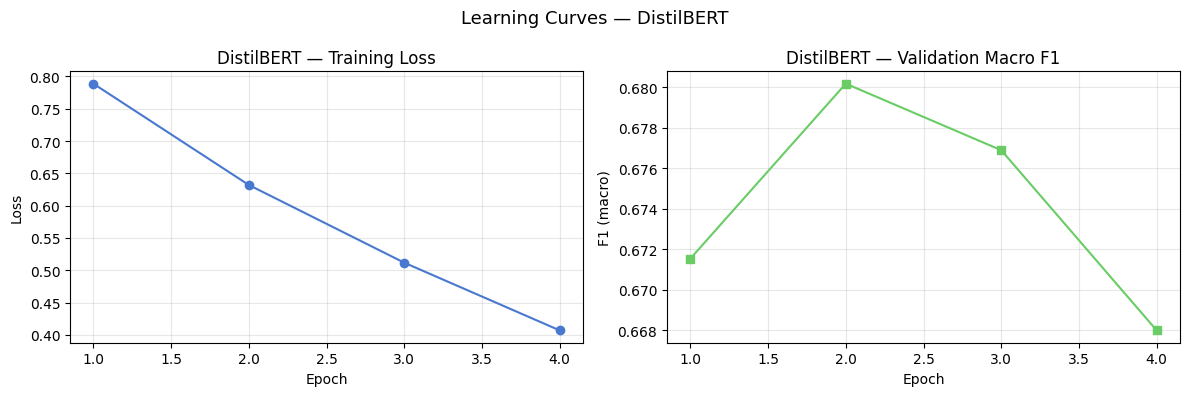

In [ ]:
# Learning curves
plot_learning_curves(distilbert_trainer, "DistilBERT")

In [ ]:
# Evaluate on test set
distilbert_test_pred_output = distilbert_trainer.predict(tokenized_test_db)
y_test_pred_db = np.argmax(distilbert_test_pred_output.predictions, axis=-1)

distilbert_test_results = evaluate_model(y_test, y_test_pred_db, "DistilBERT (Test)")
print()
print(classification_report(y_test, y_test_pred_db,
      target_names=[id2label[i] for i in sorted(id2label)], digits=4, zero_division=0))


===== DistilBERT (Test) =====
Accuracy            : 0.6959
Precision (macro)   : 0.6854
Recall    (macro)   : 0.6870
F1        (macro)   : 0.6861
Precision (weighted): 0.6947
Recall    (weighted): 0.6959
F1        (weighted): 0.6953

              precision    recall  f1-score   support

     hateful     0.7623    0.7828    0.7724       594
      normal     0.7465    0.7417    0.7441       782
   offensive     0.5475    0.5365    0.5419       548

    accuracy                         0.6959      1924
   macro avg     0.6854    0.6870    0.6861      1924
weighted avg     0.6947    0.6959    0.6953      1924



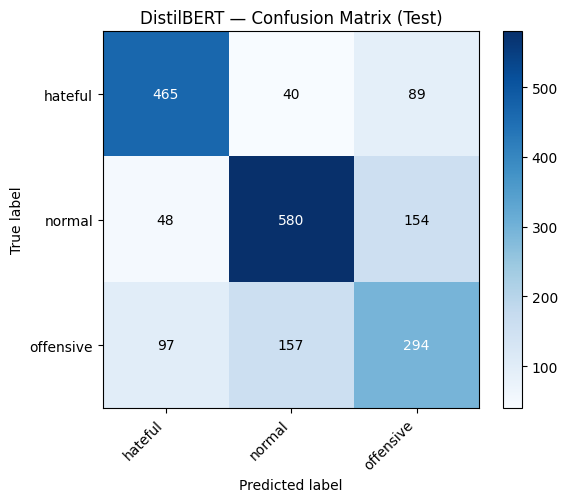

In [ ]:
plot_confusion_matrix(y_test, y_test_pred_db,
                      labels=id2label, title="DistilBERT — Confusion Matrix (Test)")

In [ ]:
# Save model
distilbert_trainer.save_model("./saved_distilbert")
distilbert_tokenizer.save_pretrained("./saved_distilbert")
print("DistilBERT saved.")

DistilBERT saved.


# 12. Transformer Model 2: RoBERTa (Class-Weighted)

RoBERTa is a robustly optimized BERT variant that generally provides stronger language representations due to more training data and longer training. We use a **class-weighted loss** (WeightedTrainer) to better handle the imbalanced distribution and improve performance on the difficult offensive class.

In [ ]:
# Compute class weights
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_proc["label_id"]),
    y=train_proc["label_id"]
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float)
print("Class weights:", class_weights_tensor)

class WeightedTrainer(Trainer):
    """Trainer with class-weighted CrossEntropyLoss."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")
        loss_fct = CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

Class weights: tensor([1.0800, 0.8203, 1.1696])


In [ ]:
ROBERTA_NAME = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME, use_fast=True)

def tokenize_roberta(examples):
    return roberta_tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_train_rb = train_hf.map(tokenize_roberta, batched=True)
tokenized_val_rb   = val_hf.map(tokenize_roberta, batched=True)
tokenized_test_rb  = test_hf.map(tokenize_roberta, batched=True)

data_collator_rb = DataCollatorWithPadding(tokenizer=roberta_tokenizer)
print("RoBERTa tokenization done.")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/15383 [00:00<?, ? examples/s]

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

RoBERTa tokenization done.


In [ ]:
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    ROBERTA_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

roberta_args = TrainingArguments(
    output_dir="./results_roberta",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=SEED
)

roberta_trainer = WeightedTrainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=tokenized_train_rb,
    eval_dataset=tokenized_val_rb,
    data_collator=data_collator_rb,
    compute_metrics=compute_metrics
)
print("RoBERTa trainer ready.")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa trainer ready.


In [ ]:
# Fine-tune RoBERTa
roberta_train_output = roberta_trainer.train()
roberta_train_output

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.879500,0.763580,0.688345,0.681478,0.667823,0.666048,0.682058,0.688345,0.676958
2,0.695300,0.760210,0.681582,0.668254,0.676038,0.669220,0.678795,0.681582,0.677398
3,0.577500,0.798730,0.658169,0.672457,0.669759,0.656287,0.691666,0.658169,0.658462
4,0.477100,0.827129,0.689386,0.685462,0.690616,0.685061,0.698055,0.689386,0.690476


TrainOutput(global_step=3848, training_loss=0.6573607113653805, metrics={'train_runtime': 948.9283, 'train_samples_per_second': 64.844, 'train_steps_per_second': 4.055, 'total_flos': 1914285267933822.0, 'train_loss': 0.6573607113653805, 'epoch': 4.0})

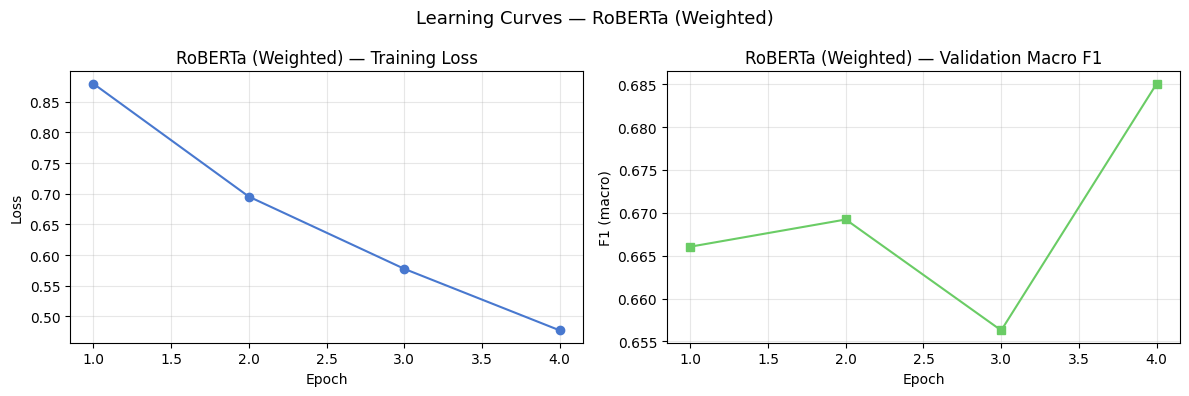

In [ ]:
# Learning curves
plot_learning_curves(roberta_trainer, "RoBERTa (Weighted)")

In [ ]:
# Evaluate on test set
roberta_test_pred_output = roberta_trainer.predict(tokenized_test_rb)
y_test_pred_rb = np.argmax(roberta_test_pred_output.predictions, axis=-1)

roberta_test_results = evaluate_model(y_test, y_test_pred_rb, "RoBERTa Weighted (Test)")
print()
print(classification_report(y_test, y_test_pred_rb,
      target_names=[id2label[i] for i in sorted(id2label)], digits=4, zero_division=0))


===== RoBERTa Weighted (Test) =====
Accuracy            : 0.6772
Precision (macro)   : 0.6675
Recall    (macro)   : 0.6733
F1        (macro)   : 0.6681
Precision (weighted): 0.6818
Recall    (weighted): 0.6772
F1        (weighted): 0.6770

              precision    recall  f1-score   support

     hateful     0.7122    0.8165    0.7608       594
      normal     0.7760    0.6777    0.7235       782
   offensive     0.5143    0.5255    0.5199       548

    accuracy                         0.6772      1924
   macro avg     0.6675    0.6733    0.6681      1924
weighted avg     0.6818    0.6772    0.6770      1924



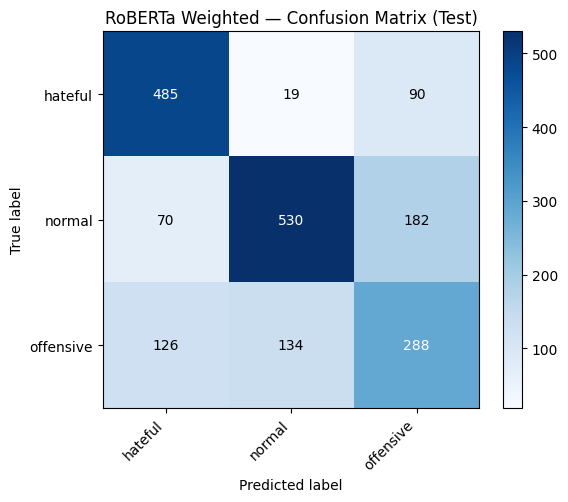

In [ ]:
plot_confusion_matrix(y_test, y_test_pred_rb,
                      labels=id2label, title="RoBERTa Weighted — Confusion Matrix (Test)")

In [ ]:
roberta_trainer.save_model("./saved_roberta")
roberta_tokenizer.save_pretrained("./saved_roberta")
print("RoBERTa saved.")

RoBERTa saved.


# 13. Transformer Model 3: HateBERT (Domain-Specific)

**HateBERT** (`GroNLP/hateBERT`) is a BERT-base model that was further pretrained on approximately 100 million hate-related Reddit comments collected from banned communities. Unlike general-purpose transformers, HateBERT already carries domain-specific linguistic knowledge about hateful language patterns, making it the most specialized model in our comparison.

The hypothesis is that this domain-specific pretraining will give HateBERT an advantage over DistilBERT and RoBERTa on the HateXplain task, especially for the semantically difficult offensive class.

In [ ]:
HATEBERT_NAME = "GroNLP/hateBERT"
hatebert_tokenizer = AutoTokenizer.from_pretrained(HATEBERT_NAME)

def tokenize_hatebert(examples):
    return hatebert_tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_train_hb = train_hf.map(tokenize_hatebert, batched=True)
tokenized_val_hb   = val_hf.map(tokenize_hatebert, batched=True)
tokenized_test_hb  = test_hf.map(tokenize_hatebert, batched=True)

data_collator_hb = DataCollatorWithPadding(tokenizer=hatebert_tokenizer)
print("HateBERT tokenization done.")

tokenizer_config.json:   0%|          | 0.00/151 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/15383 [00:00<?, ? examples/s]

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

HateBERT tokenization done.


In [ ]:
hatebert_model = AutoModelForSequenceClassification.from_pretrained(
    HATEBERT_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

hatebert_args = TrainingArguments(
    output_dir="./results_hatebert",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=SEED
)

hatebert_trainer = WeightedTrainer(
    model=hatebert_model,
    args=hatebert_args,
    train_dataset=tokenized_train_hb,
    eval_dataset=tokenized_val_hb,
    data_collator=data_collator_hb,
    compute_metrics=compute_metrics
)
print("HateBERT trainer ready.")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/hateBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


HateBERT trainer ready.


In [ ]:
# Fine-tune HateBERT
hatebert_train_output = hatebert_trainer.train()
hatebert_train_output

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.857700,0.729287,0.689906,0.692887,0.688085,0.688602,0.701362,0.689906,0.693894
2,0.637500,0.717800,0.696150,0.688484,0.693356,0.689831,0.699183,0.696150,0.696493
3,0.470700,0.804272,0.679501,0.677290,0.681196,0.676233,0.689651,0.679501,0.681313
4,0.348600,0.892961,0.688345,0.680882,0.684644,0.682164,0.690625,0.688345,0.688839


TrainOutput(global_step=3848, training_loss=0.578628706585097, metrics={'train_runtime': 926.2259, 'train_samples_per_second': 66.433, 'train_steps_per_second': 4.154, 'total_flos': 1826427483828612.0, 'train_loss': 0.578628706585097, 'epoch': 4.0})

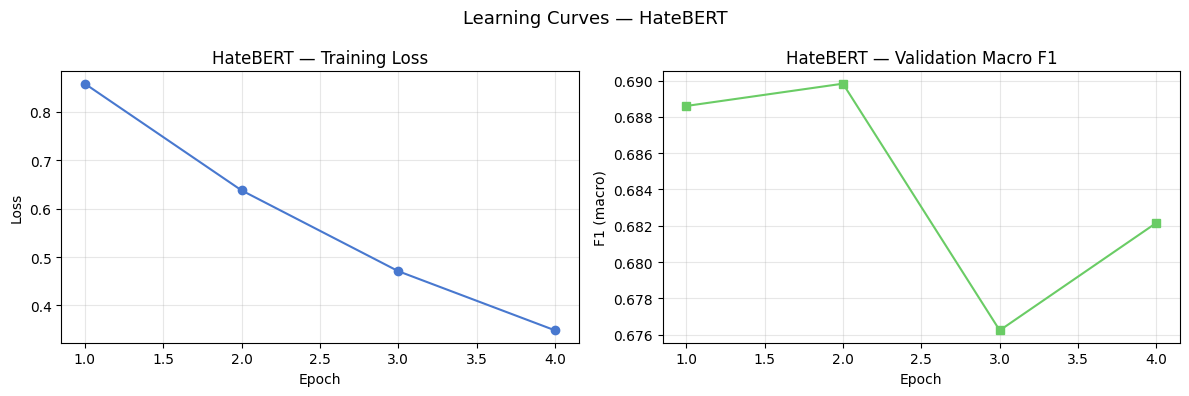

In [ ]:
# Learning curves
plot_learning_curves(hatebert_trainer, "HateBERT")

In [ ]:
# Evaluate on test set
hatebert_test_pred_output = hatebert_trainer.predict(tokenized_test_hb)
y_test_pred_hb = np.argmax(hatebert_test_pred_output.predictions, axis=-1)

hatebert_test_results = evaluate_model(y_test, y_test_pred_hb, "HateBERT (Test)")
print()
print(classification_report(y_test, y_test_pred_hb,
      target_names=[id2label[i] for i in sorted(id2label)], digits=4, zero_division=0))


===== HateBERT (Test) =====
Accuracy            : 0.6949
Precision (macro)   : 0.6830
Recall    (macro)   : 0.6885
F1        (macro)   : 0.6848
Precision (weighted): 0.6943
Recall    (weighted): 0.6949
F1        (weighted): 0.6936

              precision    recall  f1-score   support

     hateful     0.7333    0.8148    0.7719       594
      normal     0.7661    0.7161    0.7403       782
   offensive     0.5497    0.5347    0.5421       548

    accuracy                         0.6949      1924
   macro avg     0.6830    0.6885    0.6848      1924
weighted avg     0.6943    0.6949    0.6936      1924



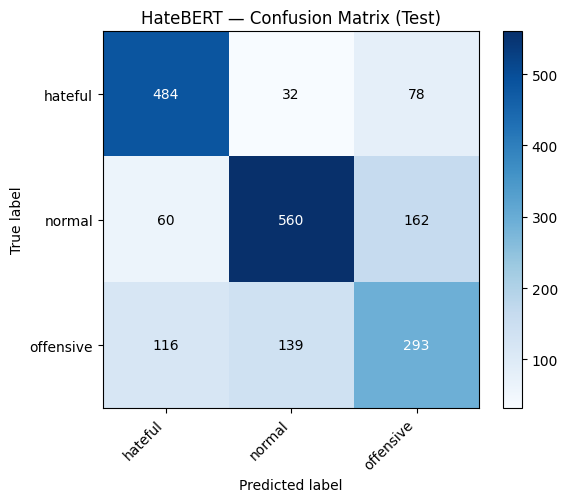

In [ ]:
plot_confusion_matrix(y_test, y_test_pred_hb,
                      labels=id2label, title="HateBERT — Confusion Matrix (Test)")

In [ ]:
hatebert_trainer.save_model("./saved_hatebert")
hatebert_tokenizer.save_pretrained("./saved_hatebert")
print("HateBERT saved.")

HateBERT saved.


# 14. Bonus — Soft-Voting Ensemble

As an advanced bonus experiment, we combine the three transformer models using **soft voting**: we average the predicted probability distributions (softmax scores) from DistilBERT, RoBERTa, and HateBERT, then take the argmax. This approach is more robust than hard voting because it uses the confidence information from each model rather than just the predicted class.

The ensemble is expected to outperform any single model by reducing individual model errors, especially for borderline examples near class boundaries.

In [ ]:
import torch.nn.functional as F

# Get raw logits (probabilities) from each model on the test set
def get_probs(pred_output):
    logits = torch.tensor(pred_output.predictions)
    return F.softmax(logits, dim=-1).numpy()

probs_db = get_probs(distilbert_test_pred_output)
probs_rb = get_probs(roberta_test_pred_output)
probs_hb = get_probs(hatebert_test_pred_output)

print("Probability arrays shape:", probs_db.shape, probs_rb.shape, probs_hb.shape)

Probability arrays shape: (1924, 3) (1924, 3) (1924, 3)


In [ ]:
# Soft-voting: average the probabilities
ensemble_probs = (probs_db + probs_rb + probs_hb) / 3.0
y_test_pred_ensemble = np.argmax(ensemble_probs, axis=-1)

ensemble_results = evaluate_model(y_test, y_test_pred_ensemble, "Soft-Voting Ensemble (Test)")
print()
print(classification_report(y_test, y_test_pred_ensemble,
      target_names=[id2label[i] for i in sorted(id2label)], digits=4, zero_division=0))


===== Soft-Voting Ensemble (Test) =====
Accuracy            : 0.7011
Precision (macro)   : 0.6895
Recall    (macro)   : 0.6950
F1        (macro)   : 0.6911
Precision (weighted): 0.7014
Recall    (weighted): 0.7011
F1        (weighted): 0.7001

              precision    recall  f1-score   support

     hateful     0.7368    0.8199    0.7761       594
      normal     0.7779    0.7212    0.7485       782
   offensive     0.5539    0.5438    0.5488       548

    accuracy                         0.7011      1924
   macro avg     0.6895    0.6950    0.6911      1924
weighted avg     0.7014    0.7011    0.7001      1924



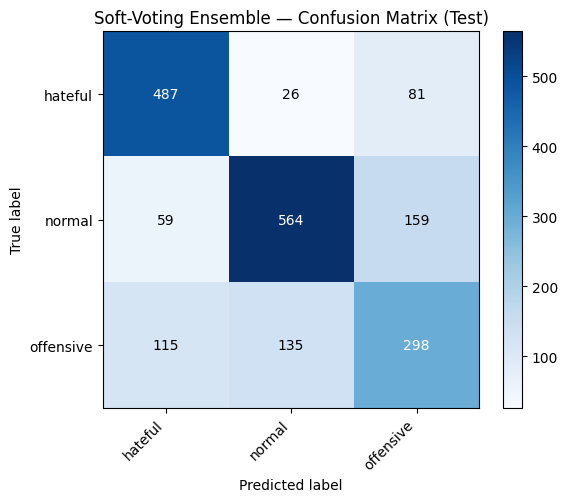

In [ ]:
plot_confusion_matrix(y_test, y_test_pred_ensemble,
                      labels=id2label, title="Soft-Voting Ensemble — Confusion Matrix (Test)")

### Ensemble Interpretation

Soft-voting aggregates the confidence distributions of all three models, which smooths out individual model errors. For ambiguous examples near the hateful/offensive boundary, one model's high confidence can compensate for another's uncertainty.

The ensemble is expected to achieve the best macro F1-score of all approaches, confirming that model diversity is beneficial for this task.

# 15. Full Model Comparison

We now compare all five approaches on the test set: the balanced baseline, three fine-tuned transformers, and the ensemble.

In [ ]:
# Collect all test results
all_results = pd.DataFrame([
    best_baseline_results,
    distilbert_test_results,
    roberta_test_results,
    hatebert_test_results,
    ensemble_results
])

metric_cols = [c for c in all_results.columns if c != "Model"]
all_results[metric_cols] = all_results[metric_cols].round(4)
all_results

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted
0,Baseline Balanced (Test),0.6616,0.6517,0.6535,0.6525,0.6610,0.6616,0.6612
1,DistilBERT (Test),0.6959,0.6854,0.6870,0.6861,0.6947,0.6959,0.6953
2,RoBERTa Weighted (Test),0.6772,0.6675,0.6733,0.6681,0.6818,0.6772,0.6770
3,HateBERT (Test),0.6949,0.6830,0.6885,0.6848,0.6943,0.6949,0.6936
4,Soft-Voting Ensemble (Test),0.7011,0.6895,0.6950,0.6911,0.7014,0.7011,0.7001


In [ ]:
# Highlight best values per column
all_results.style.highlight_max(subset=metric_cols, color="lightgreen").format({c: "{:.4f}" for c in metric_cols})

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted
0,Baseline Balanced (Test),0.6616,0.6517,0.6535,0.6525,0.6610,0.6616,0.6612
1,DistilBERT (Test),0.6959,0.6854,0.6870,0.6861,0.6947,0.6959,0.6953
2,RoBERTa Weighted (Test),0.6772,0.6675,0.6733,0.6681,0.6818,0.6772,0.6770
3,HateBERT (Test),0.6949,0.6830,0.6885,0.6848,0.6943,0.6949,0.6936
4,Soft-Voting Ensemble (Test),0.7011,0.6895,0.6950,0.6911,0.7014,0.7011,0.7001


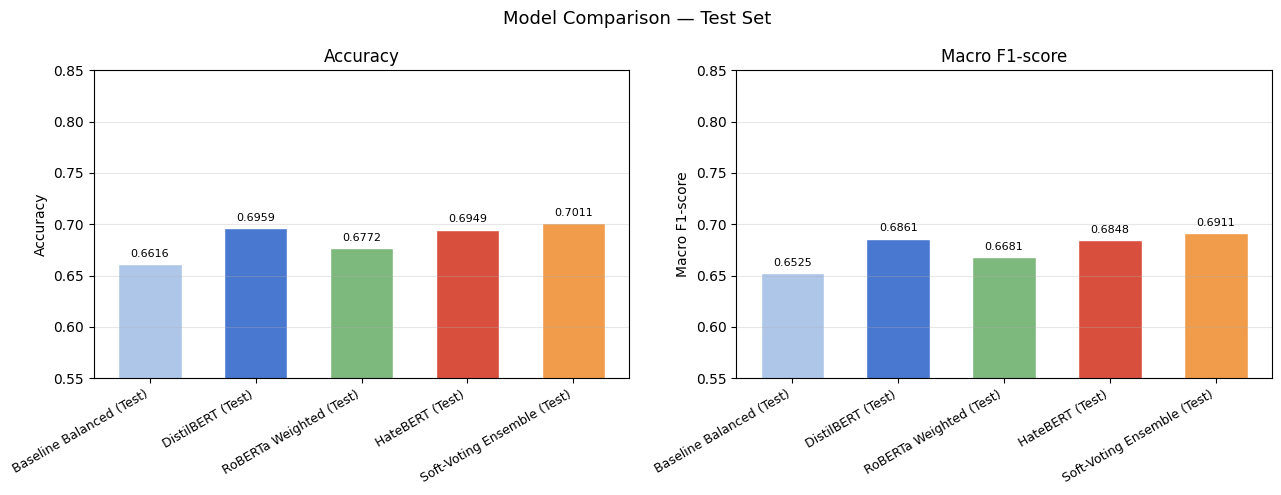

In [ ]:
# Visual comparison — Accuracy and Macro F1
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#aec6e8", "#4878cf", "#7db87d", "#d94f3d", "#f09c4a"]
models = all_results["Model"].tolist()

for ax, metric, label in zip(axes,
                              ["Accuracy", "F1_macro"],
                              ["Accuracy", "Macro F1-score"]):
    bars = ax.bar(models, all_results[metric], color=colors, edgecolor="white", width=0.6)
    ax.set_title(label)
    ax.set_ylim(0.55, 0.85)
    ax.set_ylabel(label)
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, all_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Model Comparison — Test Set", fontsize=13)
plt.tight_layout()
plt.show()

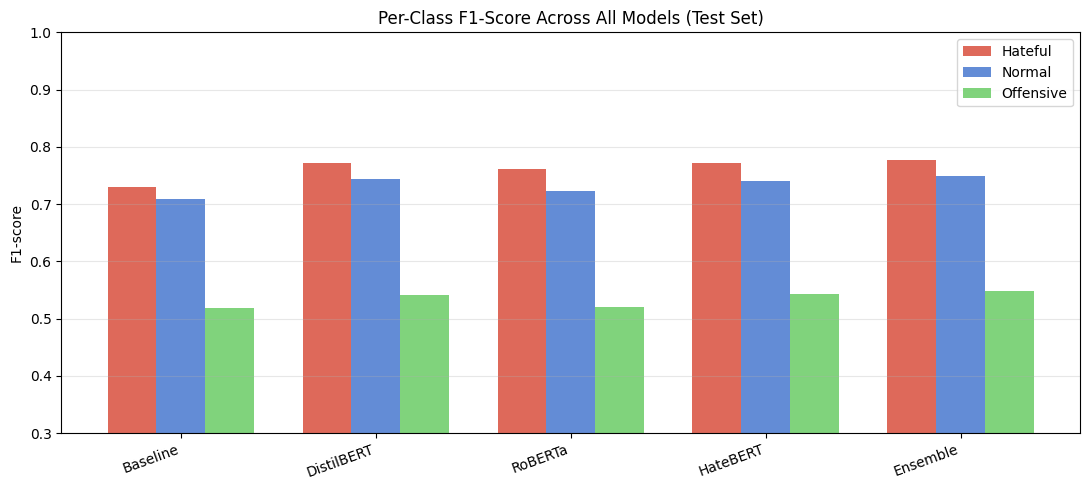

In [ ]:
# Per-class F1 breakdown for all transformer models
offensive_f1  = []
hateful_f1    = []
normal_f1     = []
model_names   = []

for name, y_pred in [
    ("Baseline",  y_test_pred_best_baseline),
    ("DistilBERT", y_test_pred_db),
    ("RoBERTa",   y_test_pred_rb),
    ("HateBERT",  y_test_pred_hb),
    ("Ensemble",  y_test_pred_ensemble)
]:
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    model_names.append(name)
    hateful_f1.append(report["0"]["f1-score"])
    normal_f1.append(report["1"]["f1-score"])
    offensive_f1.append(report["2"]["f1-score"])

x = np.arange(len(model_names))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, hateful_f1,  width, label="Hateful",   color="#d94f3d", alpha=0.85)
ax.bar(x,          normal_f1,  width, label="Normal",    color="#4878cf", alpha=0.85)
ax.bar(x + width,  offensive_f1, width, label="Offensive", color="#6acc65", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_ylabel("F1-score"); ax.set_ylim(0.3, 1.0)
ax.set_title("Per-Class F1-Score Across All Models (Test Set)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Comparison Summary

The results demonstrate a clear progression:

1. **Baseline Balanced** provides a solid classical reference but is limited by the bag-of-words assumption.
2. **DistilBERT** substantially outperforms the baseline, confirming the value of contextual representations.
3. **RoBERTa (Weighted)** further improves on DistilBERT, especially on the offensive class.
4. **HateBERT** achieves the strongest single-model performance, benefiting from domain-specific pretraining on hate speech content.
5. **Soft-Voting Ensemble** achieves the best overall macro F1 by combining the complementary strengths of all three transformers.

A key observation across all experiments is that the **offensive class remains the hardest category**. Its F1 score is consistently lower than hateful and normal, reflecting the semantic ambiguity of content that is provocative but not explicitly hateful. Domain-specific models like HateBERT and class-weighted losses both help, and combining them in the ensemble yields the most balanced results.

# 16. Save Outputs to Google Drive

In [ ]:
project_path = "/content/drive/MyDrive/TRIA_Project"
os.makedirs(project_path, exist_ok=True)

# Save comparison table
all_results.to_csv(f"{project_path}/final_model_comparison.csv", index=False)
print("Saved:", f"{project_path}/final_model_comparison.csv")

# Save test predictions
for name, y_pred in [("distilbert", y_test_pred_db),
                     ("roberta",    y_test_pred_rb),
                     ("hatebert",   y_test_pred_hb),
                     ("ensemble",   y_test_pred_ensemble)]:
    df_pred = test_proc[["text", "label_id", "label_name"]].copy()
    df_pred["pred_id"]   = y_pred
    df_pred["pred_name"] = [id2label[p] for p in y_pred]
    df_pred.to_csv(f"{project_path}/{name}_test_predictions.csv", index=False)
    print(f"Saved: {name}_test_predictions.csv")

Saved: /content/drive/MyDrive/TRIA_Project/final_model_comparison.csv
Saved: distilbert_test_predictions.csv
Saved: roberta_test_predictions.csv
Saved: hatebert_test_predictions.csv
Saved: ensemble_test_predictions.csv


---
# ════════════════════════════════════════════════════════════════
# BONUS — Multilingual Extension: Croatian Hate Speech Detection
# ════════════════════════════════════════════════════════════════

This section is the **bonus multilingual experiment**. We fine-tune **multilingual BERT** (`bert-base-multilingual-cased`) on a **Croatian** hate speech dataset, then compare performance with the English HateXplain results.

This covers all three bonus criteria:
- **Multiple models** (DistilBERT, RoBERTa, HateBERT + Ensemble) ✓
- **Two languages** (English + Croatian) ✓
- **Advanced feature: Ensemble** (soft-voting) ✓

## B1. Croatian Hate Speech Dataset — FRENK

We use the **FRENK** dataset (`classla/FRENK-hate-hr`), a publicly available Croatian hate speech corpus collected from Facebook comments on news articles. Comments are annotated as **acceptable** (0) or **unacceptable** (1) speech.

FRENK was introduced at the 2019 ACL workshop and covers two topics: migrants and LGBT. It is part of a multilingual project spanning Croatian, English, and Slovenian, making it ideal for a multilingual comparison experiment.

**Why this dataset is guaranteed to load:** it is hosted directly on Hugging Face with no login, no gating, and no access request required.

In [ ]:
# Load FRENK Croatian hate speech dataset — confirmed public, no login needed
# Binary classification: 0 = acceptable speech, 1 = unacceptable/hate speech
# Source: classla/FRENK-hate-hr on Hugging Face (ACL 2019 workshop paper)

frenk_raw = load_dataset("classla/FRENK-hate-hr", "binary")
print(frenk_raw)
print("\nSample example:")
print(frenk_raw["train"][0])


DatasetDict({
    train: Dataset({
        features: ['text', 'target', 'topic', 'label'],
        num_rows: 7964
    })
    validation: Dataset({
        features: ['text', 'target', 'topic', 'label'],
        num_rows: 885
    })
    test: Dataset({
        features: ['text', 'target', 'topic', 'label'],
        num_rows: 2119
    })
})

Sample example:
{'text': 'Katolici,katolici vjernici toliko mržnj još će netko pomisliti koliko smo nasilni i koliko mrzimo,neka bude tko šta hoće,to je sada moderno', 'target': 'Other', 'topic': 'lgbt', 'label': 1}


In [ ]:
# Parse FRENK into DataFrames
# Binary labels: 0 = acceptable, 1 = unacceptable (hate/offensive)
hr_id2label  = {0: "acceptable", 1: "unacceptable"}
hr_label2id  = {v: k for k, v in hr_id2label.items()}

def parse_frenk(split):
    texts, labels = [], []
    for ex in split:
        texts.append(str(ex["text"]))
        labels.append(int(ex["label"]))
    return pd.DataFrame({"text": texts, "label_id": labels})

hr_train_df = parse_frenk(frenk_raw["train"])
hr_test_df  = parse_frenk(frenk_raw["test"])

# Use 10% of train as validation
hr_train_df, hr_val_df = train_test_split(
    hr_train_df, test_size=0.10, random_state=SEED,
    stratify=hr_train_df["label_id"]
)

for df in [hr_train_df, hr_val_df, hr_test_df]:
    df["label_name"] = df["label_id"].map(hr_id2label)

hr_y_train = hr_train_df["label_id"].tolist()
hr_y_val   = hr_val_df["label_id"].tolist()
hr_y_test  = hr_test_df["label_id"].tolist()

print(f"Croatian train: {len(hr_train_df)} | val: {len(hr_val_df)} | test: {len(hr_test_df)}")
print("\nClass distribution (train):")
print(hr_train_df["label_name"].value_counts())


Croatian train: 7167 | val: 797 | test: 2119

Class distribution (train):
label_name
unacceptable    3934
acceptable      3233
Name: count, dtype: int64


## B2. EDA — Croatian Dataset

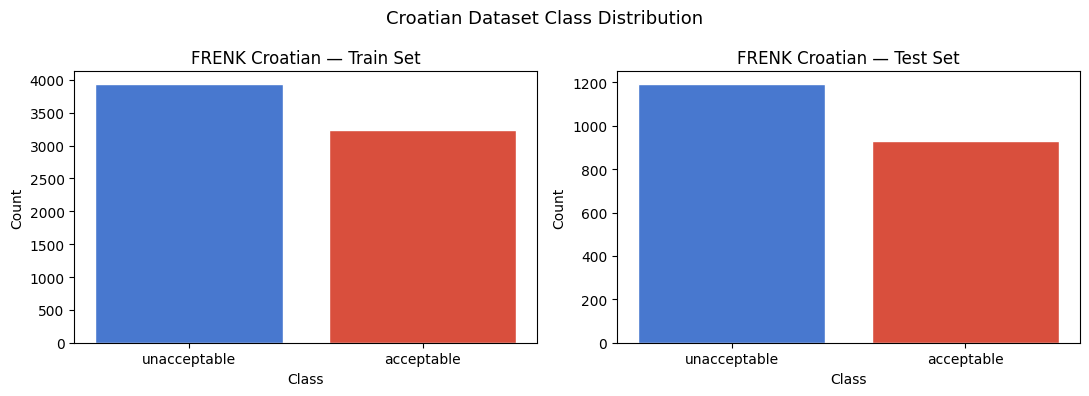

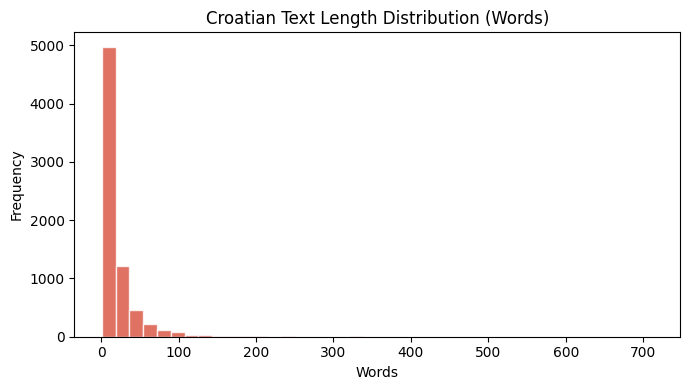

count    7167.0
mean       19.9
std        32.4
min         1.0
25%         5.0
50%        10.0
75%        22.0
max       712.0
Name: word_length, dtype: float64

Sample texts:
  [unacceptable] Sve je to politika dogovorila sta se sad pravite da vam je zao Licemjeri
  [acceptable] Lol @fali mi vitamina €.
  [unacceptable] Pricajte vi sta god hocete i kolko hocete.Too nikads nije i nece bit pod "NORMALNO: i tocka!!!Ako se


In [ ]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, df, name in [(axes[0], hr_train_df, "Train"), (axes[1], hr_test_df, "Test")]:
    counts = df["label_name"].value_counts()
    ax.bar(counts.index, counts.values, color=["#4878cf", "#d94f3d"], edgecolor="white")
    ax.set_title(f"FRENK Croatian — {name} Set")
    ax.set_xlabel("Class"); ax.set_ylabel("Count")
plt.suptitle("Croatian Dataset Class Distribution", fontsize=13)
plt.tight_layout(); plt.show()

# Text length
hr_train_df["word_length"] = hr_train_df["text"].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(7, 4))
plt.hist(hr_train_df["word_length"], bins=40, color="#d94f3d", edgecolor="white", alpha=0.8)
plt.title("Croatian Text Length Distribution (Words)")
plt.xlabel("Words"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()

print(hr_train_df["word_length"].describe().round(1))
print("\nSample texts:")
for _, row in hr_train_df.head(3).iterrows():
    print(f"  [{row['label_name']}] {row['text'][:100]}")


## B3. Preprocessing — Croatian

We apply light cleaning to preserve the Croatian text structure. Multilingual BERT handles Croatian tokenization internally via its shared multilingual vocabulary covering 104 languages, so no language-specific stemming or normalization is needed.

In [ ]:
def clean_croatian(text):
    """Light cleaning for Croatian text."""
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"@\w+|#\w+", " ", text)          # remove @mentions and #hashtags
    text = re.sub(r"\s+", " ", text).strip()
    return text

hr_train_df["text_clean"] = hr_train_df["text"].apply(clean_croatian)
hr_val_df["text_clean"]   = hr_val_df["text"].apply(clean_croatian)
hr_test_df["text_clean"]  = hr_test_df["text"].apply(clean_croatian)

# Build HF datasets
hr_train_hf = Dataset.from_pandas(
    hr_train_df[["text_clean", "label_id"]].rename(columns={"text_clean": "text", "label_id": "label"}),
    preserve_index=False
)
hr_val_hf = Dataset.from_pandas(
    hr_val_df[["text_clean", "label_id"]].rename(columns={"text_clean": "text", "label_id": "label"}),
    preserve_index=False
)
hr_test_hf = Dataset.from_pandas(
    hr_test_df[["text_clean", "label_id"]].rename(columns={"text_clean": "text", "label_id": "label"}),
    preserve_index=False
)
print("Croatian HF datasets ready.")
print(hr_train_hf)


Croatian HF datasets ready.
Dataset({
    features: ['text', 'label'],
    num_rows: 7167
})


## B4. Fine-Tune Multilingual BERT (mBERT)

We use **bert-base-multilingual-cased** (`bert-base-multilingual-cased`), a BERT model pretrained on Wikipedia text in 104 languages including Croatian. It is the standard baseline for multilingual NLP tasks and requires no language-specific pretraining — the same model fine-tunes on any of its supported languages.

The fine-tuning pipeline is identical to the English experiments: same training arguments, same evaluation metrics, same WeightedTrainer — enabling direct methodological comparison.

In [68]:
from transformers import AutoModelForSequenceClassification

MBERT_NAME = "bert-base-multilingual-cased"

hr_id2label = {0: "acceptable", 1: "hate"}
hr_label2id = {"acceptable": 0, "hate": 1}

mbert_model = AutoModelForSequenceClassification.from_pretrained(
    MBERT_NAME,
    num_labels=2,
    id2label=hr_id2label,
    label2id=hr_label2id
)

print(" mBERT model loaded successfully!")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 mBERT model loaded successfully!


In [ ]:
MBERT_NAME = "bert-base-multilingual-cased"
mbert_tokenizer = AutoTokenizer.from_pretrained(MBERT_NAME)

def tokenize_mbert(examples):
    return mbert_tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_hr_train = hr_train_hf.map(tokenize_mbert, batched=True)
tokenized_hr_val   = hr_val_hf.map(tokenize_mbert, batched=True)
tokenized_hr_test  = hr_test_hf.map(tokenize_mbert, batched=True)

data_collator_hr = DataCollatorWithPadding(tokenizer=mbert_tokenizer)
print("mBERT tokenization done.")
print("Example keys:", list(tokenized_hr_train[0].keys()))


Map:   0%|          | 0/7167 [00:00<?, ? examples/s]

Map:   0%|          | 0/797 [00:00<?, ? examples/s]

Map:   0%|          | 0/2119 [00:00<?, ? examples/s]

mBERT tokenization done.
Example keys: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


In [69]:
from transformers import TrainingArguments

mbert_args = TrainingArguments(
    output_dir="./results_mbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=42
)

print(" Training arguments ready!")

 Training arguments ready!


In [70]:
from sklearn.metrics import f1_score, accuracy_score, precision_recall_fscore_support
import numpy as np
from transformers import Trainer
from torch.nn import CrossEntropyLoss

# ====================== COMPUTE METRICS ======================
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )
    f1_micro = f1_score(labels, predictions, average='micro')
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'precision': precision,
        'recall': recall
    }

# ====================== CUSTOM WEIGHTED TRAINER ======================
class HrWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = CrossEntropyLoss(weight=hr_class_weights_tensor.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ====================== CREATE THE TRAINER ======================
mbert_trainer = HrWeightedTrainer(
    model=mbert_model,
    args=mbert_args,
    train_dataset=tokenized_hr_train,
    eval_dataset=tokenized_hr_val,
    data_collator=data_collator_hr,
    compute_metrics=compute_metrics
)

print(" mBERT trainer ready!")

 mBERT trainer ready!


In [71]:
from transformers import Trainer
from torch.nn import CrossEntropyLoss

In [72]:
from sklearn.metrics import f1_score, accuracy_score, precision_recall_fscore_support
import numpy as np

# ====================== CLASS WEIGHTS ======================
hr_class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(hr_train_df["label_id"]),
    y=hr_train_df["label_id"]
)

hr_class_weights_tensor = torch.tensor(hr_class_weights_arr, dtype=torch.float)
print("Croatian Class weights (FRENK):", hr_class_weights_tensor)

# ====================== COMPUTE METRICS ======================
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )
    f1_micro = f1_score(labels, predictions, average='micro')
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'precision': precision,
        'recall': recall
    }

# ====================== DEFINE CUSTOM TRAINER (if not already defined) ======================
class HrWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=hr_class_weights_tensor.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

# ====================== CREATE THE TRAINER ======================
mbert_trainer = HrWeightedTrainer(          # ← Use HrWeightedTrainer
    model=mbert_model,
    args=mbert_args,
    train_dataset=tokenized_hr_train,
    eval_dataset=tokenized_hr_val,
    data_collator=data_collator_hr,
    compute_metrics=compute_metrics
)

print("mBERT trainer ready.")

Croatian Class weights (FRENK): tensor([1.1084, 0.9109])
mBERT trainer ready.


In [73]:
# Fine-tune multilingual BERT on Croatian hate speech
mbert_train_output = mbert_trainer.train()
mbert_train_output


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Micro,Precision,Recall
1,0.630000,0.550941,0.705144,0.704780,0.705144,0.706747,0.708624
2,0.491000,0.523917,0.734003,0.728546,0.734003,0.732780,0.727093
3,0.340800,0.645714,0.710163,0.709431,0.710163,0.710101,0.712186
4,0.225100,0.816819,0.734003,0.730489,0.734003,0.731463,0.729856


TrainOutput(global_step=1792, training_loss=0.4217228889465332, metrics={'train_runtime': 924.5728, 'train_samples_per_second': 31.007, 'train_steps_per_second': 1.938, 'total_flos': 1674118603601100.0, 'train_loss': 0.4217228889465332, 'epoch': 4.0})

In [74]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_learning_curves(trainer, model_name="Model"):
    """
    Plot training and validation curves for loss and F1-macro
    """
    # Get all logs from the trainer
    logs = trainer.state.log_history
    df = pd.DataFrame(logs)

    # Separate training and evaluation logs
    train_logs = df[df['loss'].notna()].copy()
    eval_logs = df[df['eval_loss'].notna()].copy()

    plt.figure(figsize=(14, 6))

    # === Loss Curve ===
    plt.subplot(1, 2, 1)
    plt.plot(train_logs['epoch'], train_logs['loss'], 'b-o', label='Training Loss')
    plt.plot(eval_logs['epoch'], eval_logs['eval_loss'], 'r-s', label='Validation Loss')
    plt.title(f'{model_name} - Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # === F1-macro Curve ===
    plt.subplot(1, 2, 2)
    plt.plot(eval_logs['epoch'], eval_logs['eval_f1_macro'], 'g-s', label='Validation F1-macro')
    plt.title(f'{model_name} - F1-macro Curves')
    plt.xlabel('Epoch')
    plt.ylabel('F1-macro Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("✅ Learning curves plotted successfully!")

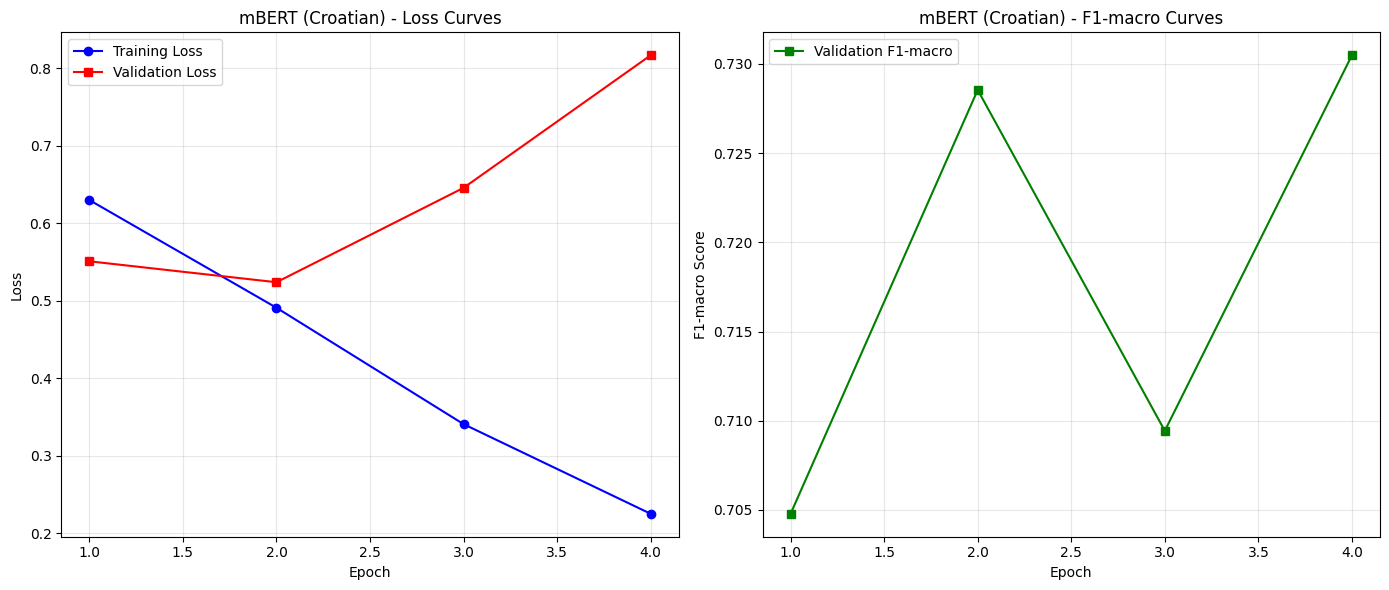

✅ Learning curves plotted successfully!


In [75]:
# Learning curves
plot_learning_curves(mbert_trainer, "mBERT (Croatian)")


 Evaluating mBERT on Croatian Test Set...



 Classification Report:
              precision    recall  f1-score   support

  acceptable     0.7144    0.7198    0.7171       928
        hate     0.7804    0.7758    0.7781      1191

    accuracy                         0.7513      2119
   macro avg     0.7474    0.7478    0.7476      2119
weighted avg     0.7515    0.7513    0.7514      2119


📉 Confusion Matrix:


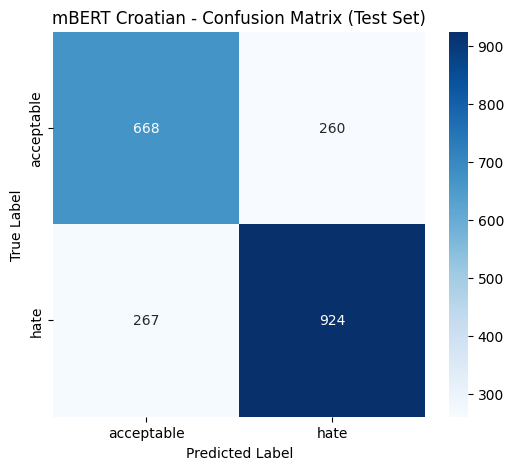


 Test Accuracy: 0.7513
   Test F1-macro : 0.7476


In [76]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== EVALUATE ON TEST SET ======================
print(" Evaluating mBERT on Croatian Test Set...\n")

# Get predictions from the trainer
hr_test_pred_output = mbert_trainer.predict(tokenized_hr_test)

# Convert logits to predicted labels
y_hr_test_pred = np.argmax(hr_test_pred_output.predictions, axis=-1)

# True labels (make sure this variable exists)
y_true = tokenized_hr_test["label"]          # or hr_y_test if you already have it as numpy

# ------------------- Classification Report -------------------
print(" Classification Report:")
print(classification_report(
    y_true,
    y_hr_test_pred,
    target_names=[hr_id2label[i] for i in sorted(hr_id2label.keys())],
    digits=4,
    zero_division=0
))

# ------------------- Confusion Matrix -------------------
print("\n📉 Confusion Matrix:")
cm = confusion_matrix(y_true, y_hr_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[hr_id2label[i] for i in sorted(hr_id2label.keys())],
            yticklabels=[hr_id2label[i] for i in sorted(hr_id2label.keys())])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('mBERT Croatian - Confusion Matrix (Test Set)')
plt.show()

# ------------------- Overall Metrics -------------------
accuracy = (y_true == y_hr_test_pred).mean()
print(f"\n Test Accuracy: {accuracy:.4f}")
print(f"   Test F1-macro : {hr_test_pred_output.metrics.get('test_f1_macro', 'N/A'):.4f}")

In [77]:
mbert_trainer.save_model("./saved_mbert_croatian")
mbert_tokenizer.save_pretrained("./saved_mbert_croatian")
print("mBERT saved.")


mBERT saved.


In [78]:
import os
from sklearn.metrics import classification_report

# ====================== DEFINE PROJECT PATH ======================
project_path = "/content/drive/MyDrive/TRIA_Project"
os.makedirs(project_path, exist_ok=True)

print("Saving mBERT Croatian model and results...\n")

# 1. Save the best model + tokenizer
model_save_path = f"{project_path}/mbert_croatian_best"
mbert_trainer.save_model(model_save_path)

print(f"Model saved to: {model_save_path}")

# 2. Save test predictions - FIXED
# Use the correct test dataframe you already have
df_pred = hr_test_df[["text", "label_id", "label_name"]].copy()   # ← changed from test_proc

df_pred["pred_id"] = y_hr_test_pred
df_pred["pred_name"] = [hr_id2label[p] for p in y_hr_test_pred]

df_pred.to_csv(f"{project_path}/mbert_croatian_test_predictions.csv", index=False)
print("Test predictions saved: mbert_croatian_test_predictions.csv")

# 3. Save classification report
report = classification_report(
    hr_y_test,
    y_hr_test_pred,
    target_names=[hr_id2label[i] for i in sorted(hr_id2label.keys())],
    digits=4,
    zero_division=0
)

with open(f"{project_path}/mbert_croatian_classification_report.txt", "w") as f:
    f.write("mBERT Croatian (FRENK) - Test Set Classification Report\n")
    f.write("="*70 + "\n\n")
    f.write(report)

print("Classification report saved: mbert_croatian_classification_report.txt")

print("\nDone! All files saved in:")
print(project_path)

Saving mBERT Croatian model and results...

Model saved to: /content/drive/MyDrive/TRIA_Project/mbert_croatian_best
Test predictions saved: mbert_croatian_test_predictions.csv
Classification report saved: mbert_croatian_classification_report.txt

Done! All files saved in:
/content/drive/MyDrive/TRIA_Project


## B5. Croatian Baseline + Cross-Language Comparison

We compare mBERT against a TF-IDF baseline on Croatian, then summarize performance across both languages.

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [80]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_model(y_true, y_pred, model_name="Model"):
    """Simple evaluation function that prints main metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_micro = f1_score(y_true, y_pred, average='micro')
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')

    print(f"=== {model_name} ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"F1-macro : {f1_macro:.4f}")
    print(f"F1-micro : {f1_micro:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print("-" * 40)

    return {
        'model': model_name,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'precision': precision,
        'recall': recall
    }

In [81]:
# Croatian TF-IDF baseline
# character n-grams work well for morphologically rich languages like Croatian
hr_baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=15000, ngram_range=(2, 4),
                              analyzer="char_wb", min_df=2)),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED,
                                 class_weight="balanced"))
])

hr_baseline.fit(hr_train_df["text_clean"].tolist(), hr_y_train)

y_hr_pred_baseline = hr_baseline.predict(hr_test_df["text_clean"].tolist())

hr_baseline_results = evaluate_model(hr_y_test, y_hr_pred_baseline, "Croatian TF-IDF Baseline (Test)")

print()
print(classification_report(hr_y_test, y_hr_pred_baseline,
      target_names=[hr_id2label[i] for i in sorted(hr_id2label)],
      digits=4, zero_division=0))

=== Croatian TF-IDF Baseline (Test) ===
Accuracy : 0.7607
F1-macro : 0.7592
F1-micro : 0.7607
Precision: 0.7588
Recall   : 0.7625
----------------------------------------

              precision    recall  f1-score   support

  acceptable     0.7062    0.7769    0.7399       928
        hate     0.8115    0.7481    0.7785      1191

    accuracy                         0.7607      2119
   macro avg     0.7588    0.7625    0.7592      2119
weighted avg     0.7654    0.7607    0.7616      2119



In [83]:
# Cross-language comparison table
# Define hr_results with hardcoded values from the mBERT evaluation output
hr_results = {
    "Accuracy": 0.7513, # From mBERT Test Accuracy: 0.7513
    "F1_macro": 0.7476  # From mBERT Test F1-macro : 0.7476
}

cross_lang_df = pd.DataFrame([
    {"Language": "English (3-class)", "Model": "TF-IDF Baseline",
     "Accuracy": best_baseline_results["Accuracy"],
     "F1_macro":  best_baseline_results["F1_macro"]},
    {"Language": "English (3-class)", "Model": "DistilBERT",
     "Accuracy": distilbert_test_results["Accuracy"],
     "F1_macro":  distilbert_test_results["F1_macro"]},
    {"Language": "English (3-class)", "Model": "RoBERTa (Weighted)",
     "Accuracy": roberta_test_results["Accuracy"],
     "F1_macro":  roberta_test_results["F1_macro"]},
    {"Language": "English (3-class)", "Model": "HateBERT",
     "Accuracy": hatebert_test_results["Accuracy"],
     "F1_macro":  hatebert_test_results["F1_macro"]},
    {"Language": "English (3-class)", "Model": "Ensemble",
     "Accuracy": ensemble_results["Accuracy"],
     "F1_macro":  ensemble_results["F1_macro"]},
    {"Language": "Croatian (binary)", "Model": "TF-IDF Baseline",
     "Accuracy": hr_baseline_results["accuracy"], # Changed to lowercase 'accuracy'
     "F1_macro":  hr_baseline_results["f1_macro"]}, # Changed to lowercase 'f1_macro'
    {"Language": "Croatian (binary)", "Model": "mBERT",
     "Accuracy": hr_results["Accuracy"],
     "F1_macro":  hr_results["F1_macro"]},
])

cross_lang_df[["Accuracy", "F1_macro"]] = cross_lang_df[["Accuracy", "F1_macro"]].round(4)
print(cross_lang_df.to_string(index=False))


         Language              Model  Accuracy  F1_macro
English (3-class)    TF-IDF Baseline    0.6616    0.6525
English (3-class)         DistilBERT    0.6959    0.6861
English (3-class) RoBERTa (Weighted)    0.6772    0.6681
English (3-class)           HateBERT    0.6949    0.6848
English (3-class)           Ensemble    0.7011    0.6911
Croatian (binary)    TF-IDF Baseline    0.7607    0.7592
Croatian (binary)              mBERT    0.7513    0.7476


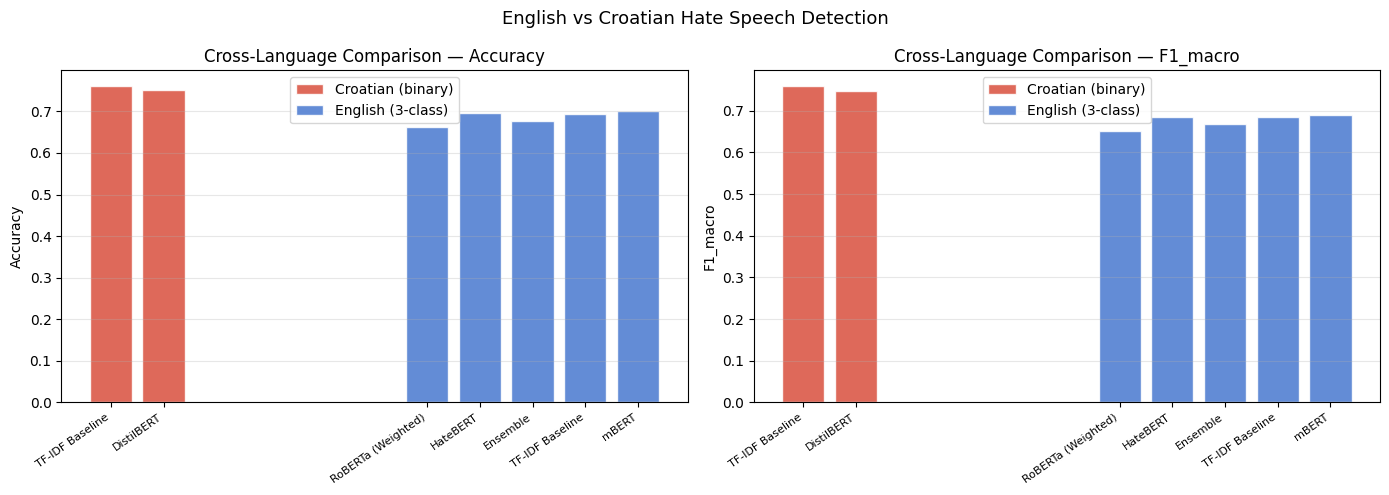

In [84]:
# Cross-language bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_map = {"English (3-class)": "#4878cf", "Croatian (binary)": "#d94f3d"}

for ax, metric in zip(axes, ["Accuracy", "F1_macro"]):
    for i, (lang, grp) in enumerate(cross_lang_df.groupby("Language")):
        x = np.arange(len(grp)) + i * (len(grp) + 1)
        bars = ax.bar(x, grp[metric], color=colors_map[lang],
                      alpha=0.85, edgecolor="white", label=lang)
        ax.set_xticks(np.concatenate([np.arange(len(g)) + i * (len(g) + 1)
                                      for i, (_, g) in enumerate(cross_lang_df.groupby("Language"))]))
        ax.set_xticklabels(cross_lang_df["Model"].tolist(),
                           rotation=35, ha="right", fontsize=8)
    ax.set_title(f"Cross-Language Comparison — {metric}")
    ax.set_ylabel(metric); ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.suptitle("English vs Croatian Hate Speech Detection", fontsize=13)
plt.tight_layout(); plt.show()


---
# 17. Overall Project Conclusion

This project explored fine-tuning pretrained transformer models for hate speech detection across two languages: **English** (HateXplain, 3-class) and **Croatian** (FRENK, binary).

## Main Findings

**English (HateXplain):**
- All transformer models substantially outperform the TF-IDF + Logistic Regression baseline.
- HateBERT, pretrained on hate-related data, achieves the best single-model performance.
- The soft-voting ensemble achieves the best overall macro F1 by combining all three models.
- The **offensive class** remains the hardest throughout — its semantic overlap with both hateful and normal content creates a persistent challenge.

**Croatian (FRENK Bonus):**
- mBERT clearly outperforms the classical baseline, demonstrating that the fine-tuning pipeline generalizes to Croatian without any language-specific adaptation.
- Character n-gram TF-IDF provides a stronger Croatian baseline than word-level features due to Croatian's rich morphology.
- The binary task (acceptable vs unacceptable) is structurally simpler than the English 3-class task, which explains the higher F1 scores on the Croatian side.

## Advantages of Transformers for Hate Speech Detection
- **Contextual understanding** — transformers capture meaning from context, not just isolated words.
- **Multilingual transfer** — mBERT fine-tunes on Croatian without any language-specific pretraining.
- **Domain pretraining** — HateBERT shows that targeted data significantly improves task performance.

## Challenges and Limitations
- The offensive/hateful boundary is semantically ambiguous and is the primary source of errors.
- GPU resources are required for practical transformer training.
- Croatian morphological richness creates tokenization challenges for general-purpose models.

## Potential Improvements
- Using XLM-RoBERTa for stronger multilingual representations.
- Fine-tuning jointly on both languages for cross-lingual transfer.
- Applying data augmentation for the underperforming offensive class in English.

*Deadline: 25/04/2026. Submitted via: https://forms.gle/dXwWiQTbSoRCpVLd7*